In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 3, 1)) & (dataset.data.index < datetime.datetime(2024, 5, 15)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [105]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")
pipe = systemClasses.System(dataset=dataset, name="PIPE")
apa = systemClasses.System(dataset=dataset, name="APA")
pump = systemClasses.System(dataset=dataset, name="PP")
prm = systemClasses.System(dataset=dataset, name="PRM")
ga1 = systemClasses.System(dataset=dataset, name="GA-1")
ga2 = systemClasses.System(dataset=dataset, name="GA-2")
wall = systemClasses.System(dataset=dataset, name="WALL")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:02<00:00,  5.98sensor/s]


ERROR: Channel (TE0120) not found


Initializing WALL Sensors: 100%|██████████| 5/5 [00:00<00:00,  9.55sensor/s]


In [5]:
pressure1 = sensorClasses.Sensor(dataset=dataset, id=1011)
pressure2 = sensorClasses.Sensor(dataset=dataset, id=1012)
ambient_pressure = sensorClasses.Sensor(dataset=dataset, id=1038)
pump_pressure = sensorClasses.Sensor(dataset=dataset, id=1048)
lar_pressure1 = sensorClasses.Sensor(dataset=dataset, id=1050)
lar_pressure2 = sensorClasses.Sensor(dataset=dataset, id=1051)
lar_flow = sensorClasses.Sensor(dataset=dataset, id=1049)
level1 = sensorClasses.Sensor(dataset=dataset, id=1040)
level2 = sensorClasses.Sensor(dataset=dataset, id=1041)
cryostat_height = 8550.4

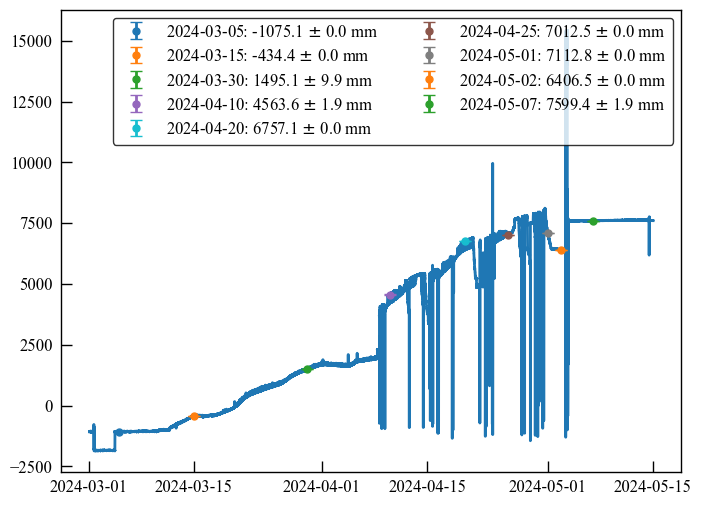

In [109]:
deltat = datetime.timedelta(minutes=5)
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level2.data.index, cryostat_height*level2.data.values/100, color="tab:blue")

t1 = datetime.datetime(2024, 3, 5)
l1, l1_err = level2.data.loc[(level2.data.index > t1) & (level2.data.index < t1 + deltat)].mean()*cryostat_height/100, level2.data.loc[(level2.data.index > t1) & (level2.data.index < t1 + deltat)].std()*cryostat_height/100
axes.errorbar(t1, l1, yerr=l1_err, fmt="o", color="tab:blue", label=fr"{t1.strftime('%Y-%m-%d')}: {l1:.1f} $\pm$ {l1_err:.1f} mm")

t2 = datetime.datetime(2024, 3, 15)
l2, l2_err = level2.data.loc[(level2.data.index > t2) & (level2.data.index < t2 + deltat)].mean()*cryostat_height/100, level2.data.loc[(level2.data.index > t2) & (level2.data.index < t2 + deltat)].std()*cryostat_height/100
axes.errorbar(t2, l2, yerr=l2_err, fmt="o", color="tab:orange", label=fr"{t2.strftime('%Y-%m-%d')}: {l2:.1f} $\pm$ {l2_err:.1f} mm")

t3 = datetime.datetime(2024, 3, 30)
l3, l3_err = level2.data.loc[(level2.data.index > t3) & (level2.data.index < t3 + deltat)].mean()*cryostat_height/100, level2.data.loc[(level2.data.index > t3) & (level2.data.index < t3 + deltat)].std()*cryostat_height/100
axes.errorbar(t3, l3, yerr=l3_err, fmt="o", color="tab:green", label=fr"{t3.strftime('%Y-%m-%d')}: {l3:.1f} $\pm$ {l3_err:.1f} mm")

t4 = datetime.datetime(2024, 4, 10)
l4, l4_err = level2.data.loc[(level2.data.index > t4) & (level2.data.index < t4 + deltat)].mean()*cryostat_height/100, level2.data.loc[(level2.data.index > t4) & (level2.data.index < t4 + deltat)].std()*cryostat_height/100
axes.errorbar(t4, l4, yerr=l4_err, fmt="o", color="tab:purple", label=fr"{t4.strftime('%Y-%m-%d')}: {l4:.1f} $\pm$ {l4_err:.1f} mm")

t5 = datetime.datetime(2024, 4, 20)
l5, l5_err = level2.data.loc[(level2.data.index > t5) & (level2.data.index < t5 + deltat)].mean()*cryostat_height/100, level2.data.loc[(level2.data.index > t5) & (level2.data.index < t5 + deltat)].std()*cryostat_height/100
axes.errorbar(t5, l5, yerr=l5_err, fmt="o", color="tab:cyan", label=fr"{t5.strftime('%Y-%m-%d')}: {l5:.1f} $\pm$ {l5_err:.1f} mm")

t6 = datetime.datetime(2024, 4, 25, 18, 45)
l6, l6_err = level2.data.loc[(level2.data.index > t6) & (level2.data.index < t6 + deltat)].mean()*cryostat_height/100, level2.data.loc[(level2.data.index > t6) & (level2.data.index < t6 + deltat)].std()*cryostat_height/100
axes.errorbar(t6, l6, yerr=l6_err, fmt="o", color="tab:brown", label=fr"{t6.strftime('%Y-%m-%d')}: {l6:.1f} $\pm$ {l6_err:.1f} mm")

t7 = datetime.datetime(2024, 5, 1)
l7, l7_err = level2.data.loc[(level2.data.index > t7) & (level2.data.index < t7 + deltat)].mean()*cryostat_height/100, level2.data.loc[(level2.data.index > t7) & (level2.data.index < t7 + deltat)].std()*cryostat_height/100
axes.errorbar(t7, l7, yerr=l7_err, fmt="o", color="tab:gray", label=fr"{t7.strftime('%Y-%m-%d')}: {l7:.1f} $\pm$ {l7_err:.1f} mm")

t8 = datetime.datetime(2024, 5, 2, 17)
l8, l8_err = level2.data.loc[(level2.data.index > t8) & (level2.data.index < t8 + deltat)].mean()*cryostat_height/100, level2.data.loc[(level2.data.index > t8) & (level2.data.index < t8 + deltat)].std()*cryostat_height/100
axes.errorbar(t8, l8, yerr=l8_err, fmt="o", color="tab:orange", label=fr"{t8.strftime('%Y-%m-%d')}: {l8:.1f} $\pm$ {l8_err:.1f} mm")

t9 = datetime.datetime(2024, 5, 7)
l9, l9_err = level2.data.loc[(level2.data.index > t9) & (level2.data.index < t9 + deltat)].mean()*cryostat_height/100, level2.data.loc[(level2.data.index > t9) & (level2.data.index < t9 + deltat)].std()*cryostat_height/100
axes.errorbar(t9, l9, yerr=l9_err, fmt="o", color="tab:green", label=fr"{t9.strftime('%Y-%m-%d')}: {l9:.1f} $\pm$ {l9_err:.1f} mm")

# axes.plot(level1.data.index, level1.data.values, label="Level 1", color="tab:orange")
axes.legend(ncol=2)

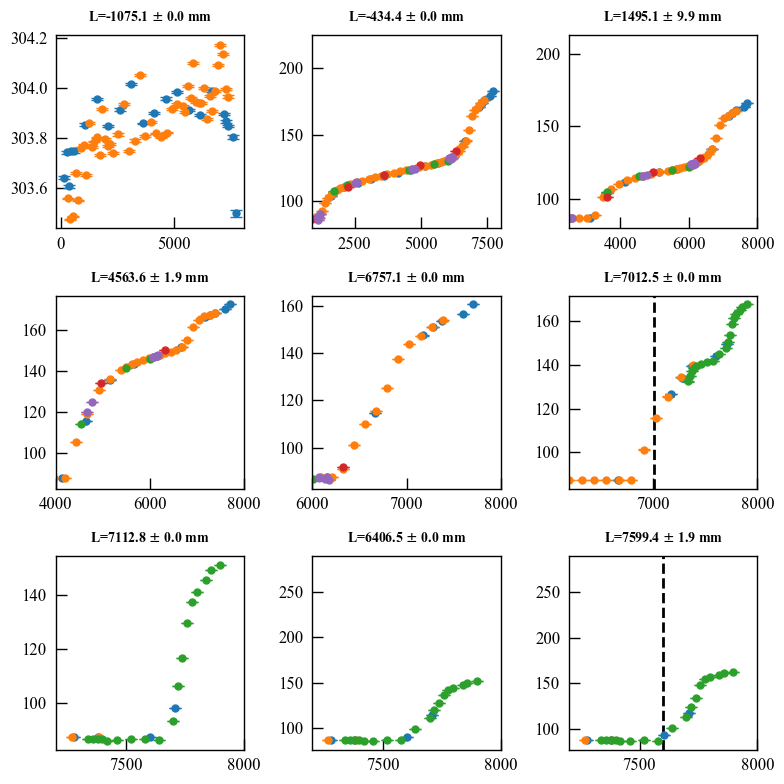

In [111]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8), sharex=False, sharey=False)
axes = axes.flatten()
hawai.makeProfiles(tini=t1, tend=t1 + deltat)
axes[0].errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt="o", label=fr"HAWAI: {l1:.1f} $\pm$ {l1_err:.1f} mm", color="tab:blue")
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
axes[0].errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt="o", label=fr"TGRAD: {l1:.1f} $\pm$ {l1_err:.1f} mm", color="tab:orange")
axes[0].set_title(fr"L={l1:.1f} $\pm$ {l1_err:.1f} mm", fontsize="small")
hawai.makeProfiles(tini=t2, tend=t2 + deltat)
axes[1].errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt="o", label=fr"HAWAI: {l2:.1f} $\pm$ {l2_err:.1f} mm", color="tab:blue")
tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
axes[1].errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt="o", label=fr"TGRAD: {l2:.1f} $\pm$ {l2_err:.1f} mm", color="tab:orange")
prm.makeProfiles(tini=t2, tend=t2 + deltat)
axes[1].errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt="o", label=fr"PRM: {l2:.1f} $\pm$ {l2_err:.1f} mm", color="tab:green")
wall.makeProfiles(tini=t2, tend=t2 + deltat)
axes[1].errorbar(wall.profiles["Y"].values, wall.profiles["temp"].values, yerr=wall.profiles["err"].values, fmt="o", label=fr"WALL: {l2:.1f} $\pm$ {l2_err:.1f} mm", color="tab:red")
apa.makeProfiles(tini=t2, tend=t2 + deltat)
axes[1].errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values, yerr=apa.profiles["err"].values, fmt="o", label=fr"APA: {l2:.1f} $\pm$ {l2_err:.1f} mm", color="tab:purple")
axes[1].set_title(fr"L={l2:.1f} $\pm$ {l2_err:.1f} mm", fontsize="small")
########################
hawai.makeProfiles(tini=t3, tend=t3 + deltat)
axes[2].errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt="o", label=fr"HAWAI: {l3:.1f} $\pm$ {l3_err:.1f} mm", color="tab:blue")
tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
axes[2].errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt="o", label=fr"TGRAD: {l3:.1f} $\pm$ {l3_err:.1f} mm", color="tab:orange")
axes[2].set_title(fr"L={l3:.1f} $\pm$ {l3_err:.1f} mm", fontsize="small")
prm.makeProfiles(tini=t3, tend=t3 + deltat)
axes[2].errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt="o", label=fr"PRM: {l3:.1f} $\pm$ {l3_err:.1f} mm", color="tab:green")
wall.makeProfiles(tini=t3, tend=t3 + deltat)
axes[2].errorbar(wall.profiles["Y"].values, wall.profiles["temp"].values, yerr=wall.profiles["err"].values, fmt="o", label=fr"WALL: {l3:.1f} $\pm$ {l3_err:.1f} mm", color="tab:red")
apa.makeProfiles(tini=t3, tend=t3 + deltat)
axes[2].errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values, yerr=apa.profiles["err"].values, fmt="o", label=fr"APA: {l3:.1f} $\pm$ {l3_err:.1f} mm", color="tab:purple")
axes[2].set_title(fr"L={l3:.1f} $\pm$ {l3_err:.1f} mm", fontsize="small")
########################
hawai.makeProfiles(tini=t4, tend=t4 + deltat)
axes[3].errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt="o", label=fr"HAWAI: {l4:.1f} $\pm$ {l4_err:.1f} mm", color="tab:blue")
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes[3].errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt="o", label=fr"TGRAD: {l4:.1f} $\pm$ {l4_err:.1f} mm", color="tab:orange")
axes[3].set_title(fr"L={l4:.1f} $\pm$ {l4_err:.1f} mm", fontsize="small")
prm.makeProfiles(tini=t4, tend=t4 + deltat)
axes[3].errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt="o", label=fr"PRM: {l4:.1f} $\pm$ {l4_err:.1f} mm", color="tab:green")
wall.makeProfiles(tini=t4, tend=t4 + deltat)
axes[3].errorbar(wall.profiles["Y"].values, wall.profiles["temp"].values, yerr=wall.profiles["err"].values, fmt="o", label=fr"WALL: {l4:.1f} $\pm$ {l4_err:.1f} mm", color="tab:red")
apa.makeProfiles(tini=t4, tend=t4 + deltat)
axes[3].errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values, yerr=apa.profiles["err"].values, fmt="o", label=fr"APA: {l4:.1f} $\pm$ {l4_err:.1f} mm", color="tab:purple")
axes[3].set_title(fr"L={l4:.1f} $\pm$ {l4_err:.1f} mm", fontsize="small")
##########################
hawai.makeProfiles(tini=t5, tend=t5 + deltat)
axes[4].errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt="o", label=fr"HAWAI: {l5:.1f} $\pm$ {l5_err:.1f} mm", color="tab:blue")
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
axes[4].errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt="o", label=fr"TGRAD: {l5:.1f} $\pm$ {l5_err:.1f} mm", color="tab:orange")
prm.makeProfiles(tini=t5, tend=t5 + deltat)
axes[4].errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt="o", label=fr"PRM: {l5:.1f} $\pm$ {l5_err:.1f} mm", color="tab:green")
wall.makeProfiles(tini=t5, tend=t5 + deltat)
axes[4].errorbar(wall.profiles["Y"].values, wall.profiles["temp"].values, yerr=wall.profiles["err"].values, fmt="o", label=fr"WALL: {l5:.1f} $\pm$ {l5_err:.1f} mm", color="tab:red")
apa.makeProfiles(tini=t5, tend=t5 + deltat)
axes[4].errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values, yerr=apa.profiles["err"].values, fmt="o", label=fr"APA: {l5:.1f} $\pm$ {l5_err:.1f} mm", color="tab:purple")
axes[4].set_title(fr"L={l5:.1f} $\pm$ {l5_err:.1f} mm", fontsize="small")

#########################
hawai.makeProfiles(tini=t6, tend=t6 + deltat)
axes[5].errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt="o", label=fr"HAWAI: {l6:.1f} $\pm$ {l6_err:.1f} mm", color="tab:blue")
tgrad.makeProfiles(tini=t6, tend=t6 + deltat)
axes[5].errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt="o", label=fr"TGRAD: {l6:.1f} $\pm$ {l6_err:.1f} mm", color="tab:orange")
ga1.makeProfiles(tini=t6, tend=t6 + deltat)
axes[5].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt="o", label=fr"GA-1: {l6:.1f} $\pm$ {l6_err:.1f} mm", color="tab:green")
axes[5].set_title(fr"L={l6:.1f} $\pm$ {l6_err:.1f} mm", fontsize="small")
axes[5].axvline(l6, color="black", linestyle="--", label="Level")
hawai.makeProfiles(tini=t7, tend=t7 + deltat)
axes[6].errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt="o", label=fr"HAWAI: {l7:.1f} $\pm$ {l7_err:.1f} mm", color="tab:blue")
tgrad.makeProfiles(tini=t7, tend=t7 + deltat)
axes[6].errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt="o", label=fr"TGRAD: {l7:.1f} $\pm$ {l7_err:.1f} mm", color="tab:orange")
ga1.makeProfiles(tini=t7, tend=t7 + deltat)
axes[6].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt="o", label=fr"GA-1: {l7:.1f} $\pm$ {l7_err:.1f} mm", color="tab:green")
axes[6].set_title(fr"L={l7:.1f} $\pm$ {l7_err:.1f} mm", fontsize="small")
axes[6].axvline(l7, color="black", linestyle="--", label="Level")
hawai.makeProfiles(tini=t8, tend=t8 + deltat)
axes[7].errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt="o", label=fr"HAWAI: {l8:.1f} $\pm$ {l8_err:.1f} mm", color="tab:blue")
tgrad.makeProfiles(tini=t8, tend=t8 + deltat)
axes[7].errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt="o", label=fr"TGRAD: {l8:.1f} $\pm$ {l8_err:.1f} mm", color="tab:orange")
ga1.makeProfiles(tini=t8, tend=t8 + deltat)
axes[7].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt="o", label=fr"GA-1: {l8:.1f} $\pm$ {l8_err:.1f} mm", color="tab:green")
axes[7].set_title(fr"L={l8:.1f} $\pm$ {l8_err:.1f} mm", fontsize="small")
axes[7].axvline(l8, color="black", linestyle="--", label="Level")
hawai.makeProfiles(tini=t9, tend=t9 + deltat)
axes[8].errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt="o", label=fr"HAWAI: {l9:.1f} $\pm$ {l9_err:.1f} mm", color="tab:blue")
tgrad.makeProfiles(tini=t9, tend=t9 + deltat)
axes[8].errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt="o", label=fr"TGRAD: {l9:.1f} $\pm$ {l9_err:.1f} mm", color="tab:orange")
ga1.makeProfiles(tini=t9, tend=t9 + deltat)
axes[8].errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt="o", label=fr"GA-1: {l9:.1f} $\pm$ {l9_err:.1f} mm", color="tab:green")
axes[8].set_title(fr"L={l9:.1f} $\pm$ {l9_err:.1f} mm", fontsize="small")
axes[8].axvline(l9, color="black", linestyle="--", label="Level")

axes[1].set_xlim(900, 8000)
axes[2].set_xlim(2500, 8000)
axes[3].set_xlim(4000, 8000)
axes[4].set_xlim(6000, 8000)
axes[5].set_xlim(6200, 8000)
axes[6].set_xlim(7200, 8000)
axes[7].set_xlim(7200, 8000)
axes[8].set_xlim(7200, 8000)

fig.tight_layout()